In [1]:
import os, time, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from tqdm import tqdm
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# ============================================================
# Cấu hình
# ============================================================
DATA_PATH   = "/kaggle/input/datasets/healthytrue/data-pj/data_PJ"
SAVE_DIR    = "./saved_models"
IMG_SIZE    = 128
BATCH_SIZE  = 32
CLASSES     = ['apple', 'banana', 'grape', 'orange', 'pomegranate']
NUM_CLASSES = len(CLASSES)
os.makedirs(SAVE_DIR, exist_ok=True)

# Transform cơ bản (dùng để extract HOG)
base_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Transform cho ResNet (224×224, ImageNet normalize)
resnet_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_ds    = ImageFolder(DATA_PATH, transform=base_tf)
loader_all = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Tổng ảnh  : {len(full_ds)}")
print(f"Số lớp    : {NUM_CLASSES}")
print(f"Tên lớp   : {CLASSES}")

Tổng ảnh  : 11965
Số lớp    : 5
Tên lớp   : ['apple', 'banana', 'grape', 'orange', 'pomegranate']


In [3]:
# ============================================================
# Trích xuất HOG features (orientations=12, cell=6)
# ============================================================
def extract_hog(loader):
    all_feat, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="HOG"):
        for img, lbl in zip(imgs, labels):
            arr  = img.permute(1, 2, 0).numpy()
            gray = np.mean(arr, axis=2)
            feat = hog(gray,
                       orientations=12,
                       pixels_per_cell=(6, 6),
                       cells_per_block=(2, 2),
                       feature_vector=True)
            all_feat.append(feat)
            all_labels.append(int(lbl))
    return np.array(all_feat), np.array(all_labels)

print("Trích xuất HOG features...")
X_hog, y_all = extract_hog(loader_all)
print(f"HOG shape: {X_hog.shape}")

# ── Chia Train/Test 80/20 ────────────────────────────────────
idx_all = np.arange(len(y_all))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.2, random_state=SEED, stratify=y_all
)
y_train = y_all[idx_train]
y_test  = y_all[idx_test]
print(f"Train: {len(y_train)}  |  Test: {len(y_test)}")

Trích xuất HOG features...


HOG: 100%|██████████| 374/374 [03:51<00:00,  1.62it/s]


HOG shape: (11965, 19200)
Train: 9572  |  Test: 2393


  Bước 1: Fine-tune ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Ep 01/15 | val_acc=0.9465 (best=0.9465)
Ep 02/15 | val_acc=0.9795 (best=0.9795)
Ep 03/15 | val_acc=0.9850 (best=0.9850)
Ep 04/15 | val_acc=0.9862 (best=0.9862)
Ep 05/15 | val_acc=0.9845 (best=0.9862)
Ep 06/15 | val_acc=0.9691 (best=0.9862)
Ep 07/15 | val_acc=0.9896 (best=0.9896)
Ep 08/15 | val_acc=0.9925 (best=0.9925)
Ep 09/15 | val_acc=0.9912 (best=0.9925)
Ep 10/15 | val_acc=0.9925 (best=0.9925)
Ep 11/15 | val_acc=0.9908 (best=0.9925)
Ep 12/15 | val_acc=0.9921 (best=0.9925)
Ep 13/15 | val_acc=0.9916 (best=0.9925)
Ep 14/15 | val_acc=0.9933 (best=0.9933)
Ep 15/15 | val_acc=0.9933 (best=0.9933)

✅ ResNet18 fine-tuned xong | Best acc: 0.9933

Bước 2: Trích xuất ResNet fine-tuned features...


ResNet-FT feat: 100%|██████████| 374/374 [01:51<00:00,  3.36it/s]


ResNet-FT features: (9572, 512)

Bước 3: Scale & Fusion features...
Fused: (9572, 19712)  = ResNet-512 + HOG-19200

Bước 4: Training ELM Ensemble...
  ELM(relu, n_hidden=4096, C=500.0)... test_acc=0.9816
  ELM(tanh, n_hidden=4096, C=200.0)... test_acc=0.9791
  ELM(sigmoid, n_hidden=2048, C=100.0)... test_acc=0.9804

Bước 5: Tìm Temperature tối ưu...
  T=0.2 → acc=0.9891
  T=0.3 → acc=0.9891
  T=0.4 → acc=0.9891
  T=0.5 → acc=0.9891
  T=0.6 → acc=0.9891
  T=0.7 → acc=0.9891
  T=0.8 → acc=0.9891
  T=1.0 → acc=0.9891

✅ Best Temperature: T=0.2  (acc=0.9891)

📊 Confidence trung bình TRƯỚC calibration: 37.6%
📊 Confidence trung bình SAU  calibration: 89.6%

  [COMBINE: ResNet-FT + HOG → ELM Ensemble + Calib]
  Accuracy : 0.9891  |  F1      : 0.9891
  Precision: 0.9891  |  Recall  : 0.9891
  Time     : 138.1s
              precision    recall  f1-score   support

       apple       0.98      0.98      0.98       489
      banana       0.99      0.99      0.99       465
       grape       0.99

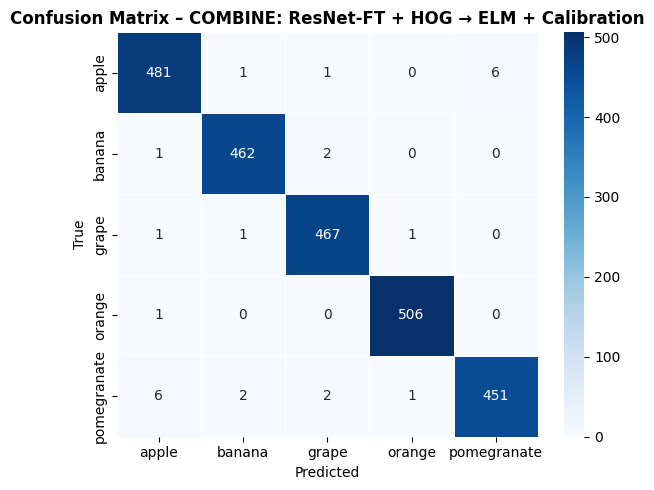

In [4]:
# ============================================================
# COMBINE: ResNet18 (fine-tuned) + HOG → ELM Ensemble
# ============================================================

# ── 1. Fine-tune ResNet18 ────────────────────────────────────
print("=" * 55)
print("  Bước 1: Fine-tune ResNet18")
print("=" * 55)

EPOCHS_RN = 15

train_ds_rn  = torch.utils.data.Subset(ImageFolder(DATA_PATH, transform=resnet_tf), idx_train)
test_ds_rn   = torch.utils.data.Subset(ImageFolder(DATA_PATH, transform=resnet_tf), idx_test)
loader_tr_rn = DataLoader(train_ds_rn, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
loader_te_rn = DataLoader(test_ds_rn,  BATCH_SIZE, shuffle=False, num_workers=2)

def build_resnet():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for p in m.parameters(): p.requires_grad = False
    for p in m.layer3.parameters(): p.requires_grad = True
    for p in m.layer4.parameters(): p.requires_grad = True
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 256), nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(256, NUM_CLASSES)
    )
    return m

resnet_model = build_resnet().to(DEVICE)
crit = nn.CrossEntropyLoss()
opt  = torch.optim.Adam(resnet_model.parameters(), lr=5e-4, weight_decay=1e-4)
sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS_RN)

best_acc = 0
for ep in range(1, EPOCHS_RN + 1):
    resnet_model.train()
    for imgs, lbs in loader_tr_rn:
        imgs, lbs = imgs.to(DEVICE), lbs.to(DEVICE)
        opt.zero_grad()
        loss = crit(resnet_model(imgs), lbs)
        loss.backward(); opt.step()
    sch.step()

    resnet_model.eval(); preds_ep, labs_ep = [], []
    with torch.no_grad():
        for imgs, lbs in loader_te_rn:
            preds_ep.extend(resnet_model(imgs.to(DEVICE)).argmax(1).cpu().numpy())
            labs_ep.extend(lbs.numpy())
    va = accuracy_score(labs_ep, preds_ep)
    if va > best_acc:
        best_acc = va
        torch.save(resnet_model.state_dict(), f"{SAVE_DIR}/resnet_finetuned.pth")
    print(f"Ep {ep:02d}/{EPOCHS_RN} | val_acc={va:.4f} (best={best_acc:.4f})")

resnet_model.load_state_dict(torch.load(f"{SAVE_DIR}/resnet_finetuned.pth"))
resnet_model.eval()
print(f"\n✅ ResNet18 fine-tuned xong | Best acc: {best_acc:.4f}")

# ── 2. Dùng ResNet fine-tuned làm backbone trích features ────
print("\nBước 2: Trích xuất ResNet fine-tuned features...")
backbone_ft = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
backbone_ft.fc = nn.Identity()
backbone_ft = backbone_ft.to(DEVICE).eval()

ft_state = {k: v for k, v in resnet_model.state_dict().items() if not k.startswith('fc')}
backbone_ft.load_state_dict(ft_state, strict=False)

def get_resnet_feats(loader):
    feats, labs = [], []
    with torch.no_grad():
        for imgs, lbs in tqdm(loader, desc="ResNet-FT feat"):
            feats.append(backbone_ft(imgs.to(DEVICE)).cpu().numpy())
            labs.extend(lbs.numpy())
    return np.vstack(feats), np.array(labs)

loader_all_rn = DataLoader(
    ImageFolder(DATA_PATH, transform=resnet_tf),
    BATCH_SIZE, shuffle=False, num_workers=2
)
X_rn_all, _ = get_resnet_feats(loader_all_rn)
X_rn_tr = X_rn_all[idx_train]
X_rn_te = X_rn_all[idx_test]
print(f"ResNet-FT features: {X_rn_tr.shape}")

# ── 3. Scale & Fusion ────────────────────────────────────────
print("\nBước 3: Scale & Fusion features...")
X_hog_tr = X_hog[idx_train]
X_hog_te = X_hog[idx_test]

sc_rn  = StandardScaler(); X_rn_tr_s  = sc_rn.fit_transform(X_rn_tr);  X_rn_te_s  = sc_rn.transform(X_rn_te)
sc_hog = StandardScaler(); X_hog_tr_s = sc_hog.fit_transform(X_hog_tr); X_hog_te_s = sc_hog.transform(X_hog_te)

X_fused_tr = np.hstack([X_rn_tr_s, X_hog_tr_s])
X_fused_te = np.hstack([X_rn_te_s, X_hog_te_s])
print(f"Fused: {X_fused_tr.shape}  = ResNet-512 + HOG-{X_hog_tr_s.shape[1]}")

# ── 4. ELM Ensemble ──────────────────────────────────────────
print("\nBước 4: Training ELM Ensemble...")

class ELM:
    def __init__(self, n_hidden=4096, C=500.0, activation='relu'):
        self.n_hidden   = n_hidden
        self.C          = C
        self.activation = activation
        self.W = self.b = self.beta = None

    def _h(self, X):
        H = X @ self.W + self.b
        if   self.activation == 'relu':    return np.maximum(0, H)
        elif self.activation == 'sigmoid': return 1 / (1 + np.exp(-np.clip(H, -500, 500)))
        else:                              return np.tanh(H)

    def fit(self, X, y):
        nc  = len(np.unique(y))
        rng = np.random.RandomState(SEED)
        self.W    = rng.randn(X.shape[1], self.n_hidden) * 0.1
        self.b    = rng.randn(1, self.n_hidden)
        H         = self._h(X)
        Y         = np.eye(nc)[y]
        self.beta = np.linalg.solve(H.T @ H + np.eye(self.n_hidden) / self.C, H.T @ Y)

    def predict_proba_raw(self, X):
        """Xác suất thô chưa calibrate."""
        scores = self._h(X) @ self.beta
        e = np.exp(scores - scores.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def predict(self, X, T=1.0):
        return np.argmax(self.predict_proba_calibrated(X, T), axis=1)

    def predict_proba_calibrated(self, X, T=0.5):
        """Temperature Scaling: T < 1 → sharpen, T > 1 → flatten."""
        proba = self.predict_proba_raw(X)
        log_p = np.log(proba + 1e-9) / T
        e     = np.exp(log_p - log_p.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

elm_configs = [
    ('relu',    4096, 500.0),
    ('tanh',    4096, 200.0),
    ('sigmoid', 2048, 100.0),
]

t0 = time.time()
elms = []
for act, nh, C in elm_configs:
    print(f"  ELM({act}, n_hidden={nh}, C={C})...", end=" ")
    e = ELM(n_hidden=nh, C=C, activation=act)
    e.fit(X_fused_tr, y_train)
    acc_te = accuracy_score(y_test, e.predict(X_fused_te))
    print(f"test_acc={acc_te:.4f}")
    elms.append(e)

# ── 5. Tìm Temperature tối ưu trên tập test ─────────────────
print("\nBước 5: Tìm Temperature tối ưu...")
best_T, best_acc_T = 1.0, 0.0
for T in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    proba_avg = np.mean([e.predict_proba_calibrated(X_fused_te, T) for e in elms], axis=0)
    acc_T = accuracy_score(y_test, np.argmax(proba_avg, axis=1))
    print(f"  T={T:.1f} → acc={acc_T:.4f}")
    if acc_T > best_acc_T:
        best_acc_T = acc_T
        best_T = T

print(f"\n✅ Best Temperature: T={best_T}  (acc={best_acc_T:.4f})")
TEMPERATURE = best_T

# ── 6. Đánh giá với Temperature tốt nhất ────────────────────
proba_avg   = np.mean([e.predict_proba_calibrated(X_fused_te, TEMPERATURE) for e in elms], axis=0)
preds_final = np.argmax(proba_avg, axis=1)
elapsed = time.time() - t0

# Kiểm tra confidence trung bình trước và sau calibration
proba_raw  = np.mean([e.predict_proba_raw(X_fused_te) for e in elms], axis=0)
conf_before = proba_raw.max(axis=1).mean() * 100
conf_after  = proba_avg.max(axis=1).mean() * 100
print(f"\n📊 Confidence trung bình TRƯỚC calibration: {conf_before:.1f}%")
print(f"📊 Confidence trung bình SAU  calibration: {conf_after:.1f}%")

acc  = accuracy_score(y_test, preds_final)
prec = precision_score(y_test, preds_final, average='weighted', zero_division=0)
rec  = recall_score(y_test, preds_final, average='weighted', zero_division=0)
f1   = f1_score(y_test, preds_final, average='weighted', zero_division=0)

print(f"\n{'='*55}")
print(f"  [COMBINE: ResNet-FT + HOG → ELM Ensemble + Calib]")
print(f"  Accuracy : {acc:.4f}  |  F1      : {f1:.4f}")
print(f"  Precision: {prec:.4f}  |  Recall  : {rec:.4f}")
print(f"  Time     : {elapsed:.1f}s")
print(f"{'='*55}")
print(classification_report(y_test, preds_final, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(y_test, preds_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
plt.title("Confusion Matrix – COMBINE: ResNet-FT + HOG → ELM + Calibration", fontweight='bold')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("cm_combine.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ============================================================
# Lưu toàn bộ model & scaler
# ============================================================

# ResNet fine-tuned
torch.save(resnet_model.state_dict(), f"{SAVE_DIR}/resnet_finetuned.pth")
print("✅ Đã lưu: resnet_finetuned.pth")

# ELM Ensemble
for i, (e, (act, nh, C)) in enumerate(zip(elms, elm_configs)):
    joblib.dump({'W': e.W, 'b': e.b, 'beta': e.beta,
                 'n_hidden': e.n_hidden, 'C': e.C, 'activation': e.activation},
                f"{SAVE_DIR}/elm_{i}_{act}.joblib")
print("✅ Đã lưu: elm_0_relu.joblib, elm_1_tanh.joblib, elm_2_sigmoid.joblib")

# Scaler
joblib.dump(sc_rn,  f"{SAVE_DIR}/sc_resnet.joblib")
joblib.dump(sc_hog, f"{SAVE_DIR}/sc_hog.joblib")
print("✅ Đã lưu: sc_resnet.joblib, sc_hog.joblib")

# Temperature tối ưu
joblib.dump({'temperature': TEMPERATURE}, f"{SAVE_DIR}/temperature.joblib")
print(f"✅ Đã lưu: temperature.joblib  (T={TEMPERATURE})")

# HOG & index
np.save(f"{SAVE_DIR}/X_hog.npy",     X_hog)
np.save(f"{SAVE_DIR}/idx_train.npy", idx_train)
np.save(f"{SAVE_DIR}/idx_test.npy",  idx_test)
print("✅ Đã lưu: X_hog.npy, idx_train.npy, idx_test.npy")

print(f"\n📁 Tất cả file trong {SAVE_DIR}:")
print(os.listdir(SAVE_DIR))

✅ Đã lưu: resnet_finetuned.pth
✅ Đã lưu: elm_0_relu.joblib, elm_1_tanh.joblib, elm_2_sigmoid.joblib
✅ Đã lưu: sc_resnet.joblib, sc_hog.joblib
✅ Đã lưu: temperature.joblib  (T=0.2)
✅ Đã lưu: X_hog.npy, idx_train.npy, idx_test.npy

📁 Tất cả file trong ./saved_models:
['sc_hog.joblib', 'idx_train.npy', 'elm_1_tanh.joblib', 'resnet_finetuned.pth', 'elm_2_sigmoid.joblib', 'sc_resnet.joblib', 'idx_test.npy', 'X_hog.npy', 'elm_0_relu.joblib', 'temperature.joblib']


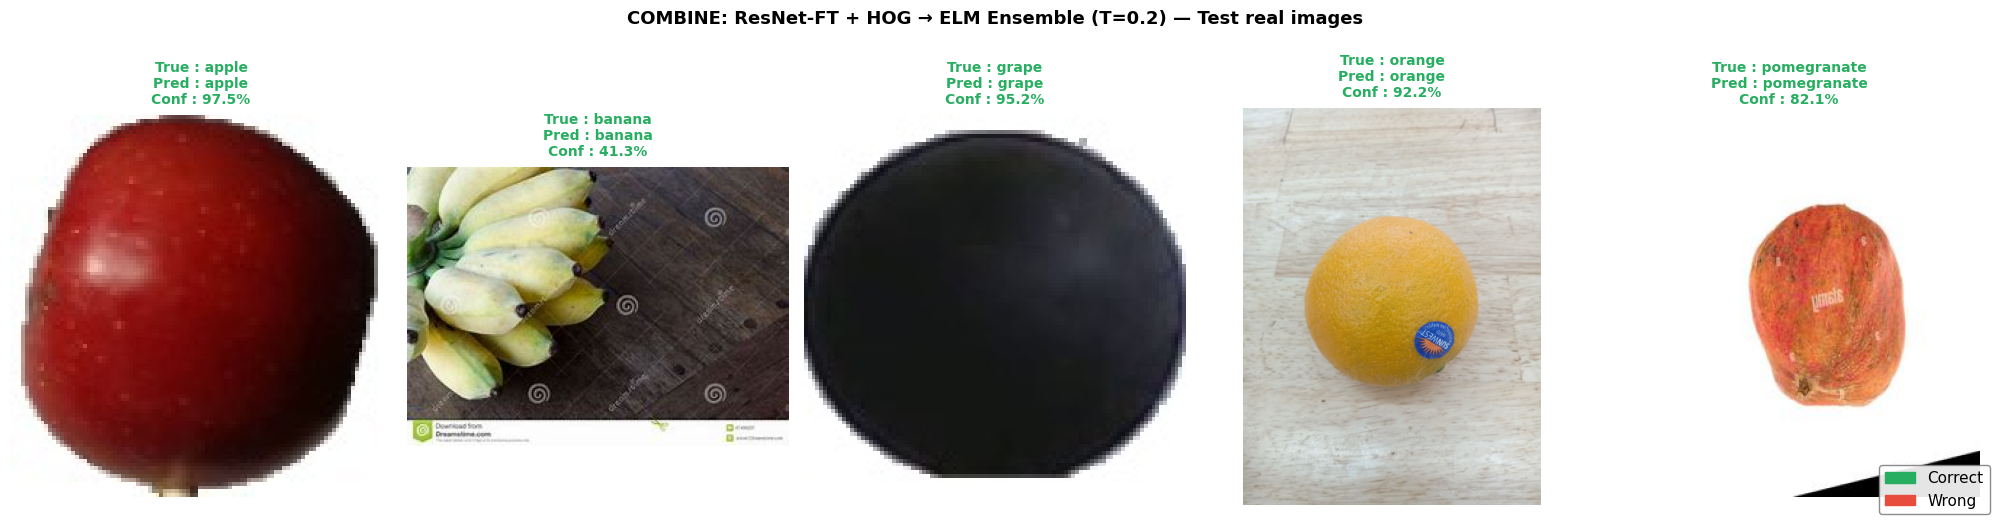

In [6]:
# ============================================================
# Test ảnh thật – COMBINE: ResNet-FT + HOG → ELM Ensemble
# Lấy ngẫu nhiên 1 ảnh mỗi class từ tập test
# ============================================================
random.seed(None)

ds_display = ImageFolder(DATA_PATH)
ds_infer   = ImageFolder(DATA_PATH, transform=resnet_tf)
ds_base    = ImageFolder(DATA_PATH, transform=base_tf)

# Chọn 1 ảnh random mỗi class từ idx_test
chosen = {}
shuffled = list(idx_test)
random.shuffle(shuffled)
for i in shuffled:
    _, lbl = ds_display[i]
    if lbl not in chosen:
        chosen[lbl] = i
    if len(chosen) == NUM_CLASSES:
        break
selected_indices = [chosen[k] for k in sorted(chosen.keys())]

def predict_combine(idx):
    _, true_lbl = ds_display[idx]

    # ResNet feature
    inp_rn, _ = ds_infer[idx]
    with torch.no_grad():
        feat_rn = backbone_ft(inp_rn.unsqueeze(0).to(DEVICE)).cpu().numpy()

    # HOG feature
    img_arr  = ds_base[idx][0].permute(1, 2, 0).numpy()
    gray     = np.mean(img_arr, axis=2)
    feat_hog = hog(gray, orientations=12, pixels_per_cell=(6, 6),
                   cells_per_block=(2, 2), feature_vector=True).reshape(1, -1)

    # Fuse & predict với Temperature Scaling
    fused     = np.hstack([sc_rn.transform(feat_rn), sc_hog.transform(feat_hog)])
    proba_avg = np.mean([e.predict_proba_calibrated(fused, TEMPERATURE) for e in elms], axis=0)
    pred      = int(np.argmax(proba_avg))
    conf      = float(proba_avg[0][pred]) * 100
    return pred, conf, true_lbl

# ── Vẽ ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 5))
fig.suptitle(f"COMBINE: ResNet-FT + HOG → ELM Ensemble (T={TEMPERATURE}) — Test real images",
             fontsize=13, fontweight='bold', y=1.02)

for ax, idx in zip(axes, selected_indices):
    raw_img, true_lbl = ds_display[idx]
    true_name = CLASSES[true_lbl]

    pred_lbl, conf, _ = predict_combine(idx)
    pred_name = CLASSES[pred_lbl]
    correct   = (pred_lbl == true_lbl)
    color     = '#27ae60' if correct else '#e74c3c'

    ax.imshow(raw_img)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(5)
    ax.set_title(
        f"True : {true_name}\nPred : {pred_name}\nConf : {conf:.1f}%",
        fontsize=10, color=color, fontweight='bold', pad=8
    )

fig.legend(
    handles=[
        mpatches.Patch(color='#27ae60', label='Correct'),
        mpatches.Patch(color='#e74c3c', label='Wrong'),
    ],
    loc='lower right', fontsize=11, framealpha=0.9, edgecolor='gray'
)

plt.tight_layout()

plt.show()


In [7]:
# ============================================================
# Load lại model để dùng (không cần train lại)
# ============================================================

# ResNet backbone
backbone_ft = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
backbone_ft.fc = nn.Identity()
resnet_full = build_resnet()
resnet_full.load_state_dict(torch.load(f"{SAVE_DIR}/resnet_finetuned.pth", map_location=DEVICE))
ft_state = {k: v for k, v in resnet_full.state_dict().items() if not k.startswith('fc')}
backbone_ft.load_state_dict(ft_state, strict=False)
backbone_ft = backbone_ft.to(DEVICE).eval()
print("✅ Đã load ResNet backbone")

# ELM Ensemble
elm_configs = [('relu', 4096, 500.0), ('tanh', 4096, 200.0), ('sigmoid', 2048, 100.0)]
elms = []
for i, (act, nh, C) in enumerate(elm_configs):
    data = joblib.load(f"{SAVE_DIR}/elm_{i}_{act}.joblib")
    e = ELM(n_hidden=data['n_hidden'], C=data['C'], activation=data['activation'])
    e.W = data['W']; e.b = data['b']; e.beta = data['beta']
    elms.append(e)
print("✅ Đã load ELM Ensemble (3 models)")

# Scaler
sc_rn  = joblib.load(f"{SAVE_DIR}/sc_resnet.joblib")
sc_hog = joblib.load(f"{SAVE_DIR}/sc_hog.joblib")
print("✅ Đã load Scaler")

# Temperature
TEMPERATURE = joblib.load(f"{SAVE_DIR}/temperature.joblib")['temperature']
print(f"✅ Đã load Temperature: T={TEMPERATURE}")

print("\n🚀 Sẵn sàng predict!")

✅ Đã load ResNet backbone
✅ Đã load ELM Ensemble (3 models)
✅ Đã load Scaler
✅ Đã load Temperature: T=0.2

🚀 Sẵn sàng predict!
